In [1]:
import pandas as pd 
import sys
sys.path.append('../../code')
import plot_of_experiment_data 
import matplotlib.pyplot as plt
import matplotlib
import warnings
import numpy as np 
warnings.filterwarnings("ignore", message="findfont: Font family 'Arial' not found.")
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'

In [2]:
def std_err(arr):
    err = np.nanstd(arr,axis=0)/np.sqrt(np.sum(~np.isnan(arr),axis=0))
    return err

def pval_to_asterisks(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


In [3]:
fpath = '/volume_4/research/seongbong/flywire/geosmin_project/figure/figure3_olfactory_pathway/data/kir2.1_MB.xlsx'
sheets = pd.ExcelFile(fpath)
sheets = sheets.sheet_names
# sheets = ['']
data_df_figH = {}
for s in sheets:
    df = pd.read_excel(fpath,s)
    data_df_figH[s] = df
    
mean_df_figH = pd.DataFrame(index=sheets,columns=['sugar','sugar+geosmin'])
std_df_figH = pd.DataFrame(index=sheets,columns=['sugar','sugar+geosmin'])
for i,df in data_df_figH.items():
    mean_df_figH.loc[i] = df.mean()
    std_df_figH.loc[i] = std_err(df)
    

In [4]:
data_df_figH

{'MB247>TNT (active)':       sugar  sugar+geosmin
 0  0.833333       0.291667
 1  0.708333       0.416667
 2  0.541667       0.208333
 3  0.458333       0.208333
 4  0.583333       0.333333
 5  0.625000       0.333333,
 'MB247>TNT (inactive)':       sugar  sugar+geosmin
 0  0.625000       0.291667
 1  0.708333       0.375000
 2  0.583333       0.250000
 3  0.416667       0.166667
 4  0.875000       0.375000
 5  0.583333       0.333333}

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

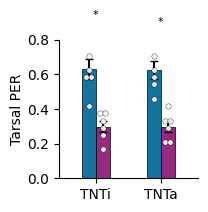

In [5]:
fig,ax = plt.subplots(1,1,figsize=(1.8,1.8))

ax,stat_all = plot_of_experiment_data.draw_paired_bar_figure(
    data=data_df_figH,
    mean_df=mean_df_figH,
    err_df=std_df_figH,
    ax=ax,
#     alternative='two-sided',
    conds=['MB247>TNT (inactive)', 'MB247>TNT (active)'],
    groups=['sugar', 'sugar+geosmin'],
    get_values=lambda data, cond, group: data[cond][group],
    stat_pairs=[
        (('MB247>TNT (inactive)', 'sugar'), ('MB247>TNT (inactive)', 'sugar+geosmin')),
        (('MB247>TNT (active)', 'sugar'), ('MB247>TNT (active)', 'sugar+geosmin'))
    ],
    colors=('#13739E', '#952B7E'),
    ylabel='Tarsal PER',
    xtick_func=lambda c: c.split('>')[0],
    ylim=(0, 0.8),
    yticks=np.round(np.arange(0, .81, .2), 2)
)
ax.set_xticks([0,0.7],['TNTi','TNTa'])

In [6]:
stat_all

[(21.0, 0.015625), (21.0, 0.015625)]

In [7]:
data_df_figH


{'MB247>TNT (active)':       sugar  sugar+geosmin
 0  0.833333       0.291667
 1  0.708333       0.416667
 2  0.541667       0.208333
 3  0.458333       0.208333
 4  0.583333       0.333333
 5  0.625000       0.333333,
 'MB247>TNT (inactive)':       sugar  sugar+geosmin
 0  0.625000       0.291667
 1  0.708333       0.375000
 2  0.583333       0.250000
 3  0.416667       0.166667
 4  0.875000       0.375000
 5  0.583333       0.333333}